# Preparación y perfilamiento de datos

**Proyecto final · Herramientas de Visualización para BI · Grupo 2**
Fabricante nacional de electrodomésticos · Audiencia: gerencia comercial y de operaciones.

Este notebook documenta cómo se revisó y transformó el dataset antes de construir el dashboard:

1. Carga y vista general
2. Unidad de observación
3. Clasificación de variables
4. Tipos de datos
5. Valores faltantes
6. Rangos, categorías e inconsistencias
7. ¿Los montos son por unidad o por línea?
8. Costo estimado y margen
9. Cobertura temporal
10. Meta de entrega
11. Transformación con `data.limpiar()`
12. Registros excluidos
13. Validación de los KPI
14. Exportación del CSV procesado
15. Bitácora de decisiones y limitaciones

La limpieza **no se escribe dos veces**: el notebook usa la misma función `data.limpiar()` que usa la app, así que lo que se valida aquí es exactamente lo que ve el dashboard.

> Ejecutar desde la carpeta raíz del repositorio (donde está `app.py`).

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import streamlit

# Streamlit avisa que no hay una app corriendo al importar data.py; aquí no aplica
logging.getLogger("streamlit.runtime.caching.cache_data_api").setLevel(logging.ERROR)

import data
import kpis
from theme import COLORES, fmt_millones, fmt_pct, fmt_nota, fmt_entero

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": COLORES["texto_sec"], "axes.labelcolor": COLORES["texto"],
                     "xtick.color": COLORES["texto_sec"], "ytick.color": COLORES["texto_sec"]})

## 1. Carga y vista general

El dataset es **sintético y anonimizado**, entregado por el curso para el Grupo 2 (`02_fabricante_electrodomesticos.csv`).

In [2]:
raw = pd.read_csv(data.RUTA_RAW)
print(f"Filas: {raw.shape[0]:,} · Columnas: {raw.shape[1]}".replace(",", "."))
raw.head()

Filas: 56.000 · Columnas: 19


,id_linea_venta,fecha,ciudad,departamento,region,categoria,subcategoria,canal,clasificacion_energetica,precio_lista_cop,descuento_pct,ingreso_neto_cop,costo_estimado_cop,unidades,dias_entrega,devolucion_30_dias,motivo_devolucion,garantia_meses,calificacion_cliente_1a5
0,ELEC-000001,2026-02-26,Barranquilla,Atlántico,Caribe,Lavado,Línea C,Retail aliado,No aplica,3435697,11.67,3034846,2147688,1,5,No,NaN,12,3.0
1,ELEC-000002,2025-05-17,Barranquilla,Atlántico,Caribe,Cocción,Línea C,Tienda propia,A,2052050,6.63,1916057,1430874,2,7,No,NaN,24,3.0
2,ELEC-000003,2025-12-16,Cartagena,Bolívar,Caribe,Refrigeración,Línea A,Retail aliado,A,2433262,9.25,2208128,1435958,1,3,No,NaN,12,4.0
3,ELEC-000004,2025-11-29,Santa Marta,Magdalena,Caribe,Climatización,Línea C,E-commerce,B,1650623,16.34,1380848,874876,1,5,No,NaN,36,3.0
4,ELEC-000005,2025-12-13,Medellín,Antioquia,Noroccidente,Lavado,Línea A,E-commerce,C,2743663,8.66,2506075,1648857,1,0,No,NaN,24,3.0


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_linea_venta            56000 non-null  str    
 1   fecha                     56000 non-null  str    
 2   ciudad                    56000 non-null  str    
 3   departamento              56000 non-null  str    
 4   region                    56000 non-null  str    
 5   categoria                 56000 non-null  str    
 6   subcategoria              56000 non-null  str    
 7   canal                     56000 non-null  str    
 8   clasificacion_energetica  56000 non-null  str    
 9   precio_lista_cop          56000 non-null  int64  
 10  descuento_pct             56000 non-null  float64
 11  ingreso_neto_cop          56000 non-null  int64  
 12  costo_estimado_cop        56000 non-null  int64  
 13  unidades                  56000 non-null  int64  
 14  dias_entrega     

## 2. Unidad de observación

Se revisa si `id_linea_venta` identifica de forma única cada fila y si hay filas repetidas.

In [4]:
print("IDs únicos:", raw["id_linea_venta"].nunique(), "de", len(raw))
print("Filas duplicadas completas:", raw.duplicated().sum())
print("Filas duplicadas ignorando el ID:", raw.drop(columns="id_linea_venta").duplicated().sum())

IDs únicos: 56000 de 56000
Filas duplicadas completas: 0
Filas duplicadas ignorando el ID: 0


**Conclusión.** Cada fila es **una línea de venta**: un producto (categoría y subcategoría) vendido en una fecha, ciudad y canal, con 1 a 3 unidades, y su seguimiento posterior (días de entrega, devolución a 30 días y calificación). No hay IDs ni filas duplicadas.

## 3. Clasificación de variables

Cada variable se clasifica por su naturaleza y por el rol que cumple en el dashboard: **filtro** (barra lateral), **dimensión** (para segmentar o agrupar), **métrica** (para calcular KPI) o **identificador**.

In [5]:
diccionario = pd.DataFrame([
    ("id_linea_venta", "Texto", "Identificador", "Identificador", "Código único de la línea de venta"),
    ("fecha", "Temporal", "Fecha diaria", "Filtro y dimensión", "Fecha de la venta"),
    ("ciudad", "Categórica nominal", "Geográfica", "Dimensión", "Ciudad de la venta (12)"),
    ("departamento", "Categórica nominal", "Geográfica", "Dimensión", "Departamento de la ciudad (12)"),
    ("region", "Categórica nominal", "Geográfica", "Filtro y dimensión", "Región del país (7)"),
    ("categoria", "Categórica nominal", "Producto", "Filtro y dimensión", "Categoría del producto (5)"),
    ("subcategoria", "Categórica nominal", "Producto", "Dimensión", "Línea dentro de la categoría (A–D)"),
    ("canal", "Categórica nominal", "Comercial", "Filtro y dimensión", "Canal de venta (4)"),
    ("clasificacion_energetica", "Categórica ordinal", "Producto", "Dimensión", "Etiqueta energética A, B, C o No aplica"),
    ("precio_lista_cop", "Cuantitativa continua", "COP por unidad", "Métrica", "Precio de lista antes del descuento"),
    ("descuento_pct", "Cuantitativa continua", "Porcentaje", "Métrica y dimensión", "Descuento aplicado, en %"),
    ("ingreso_neto_cop", "Cuantitativa continua", "COP por unidad", "Métrica", "Precio después del descuento"),
    ("costo_estimado_cop", "Cuantitativa continua", "COP por unidad", "Métrica", "Costo estimado del producto"),
    ("unidades", "Cuantitativa discreta", "Conteo", "Métrica", "Unidades de la línea (1 a 3)"),
    ("dias_entrega", "Cuantitativa discreta", "Días", "Métrica y dimensión", "Días entre la venta y la entrega"),
    ("devolucion_30_dias", "Categórica binaria", "Sí / No", "Métrica", "Si la línea se devolvió en 30 días"),
    ("motivo_devolucion", "Categórica nominal", "Texto", "Dimensión", "Motivo, solo en líneas devueltas"),
    ("garantia_meses", "Cuantitativa discreta", "Meses (12, 24, 36)", "Dimensión", "Garantía del producto"),
    ("calificacion_cliente_1a5", "Categórica ordinal", "Escala 1 a 5", "Métrica", "Calificación del cliente"),
], columns=["variable", "naturaleza", "tipo / unidad", "rol en el dashboard", "descripción"])
diccionario["tipo en pandas"] = diccionario["variable"].map(raw.dtypes.astype(str))
diccionario

,variable,naturaleza,tipo / unidad,rol en el dashboard,descripción,tipo en pandas
0,id_linea_venta,Texto,Identificador,Identificador,Código único de la línea de venta,str
1,fecha,Temporal,Fecha diaria,Filtro y dimensión,Fecha de la venta,str
2,ciudad,Categórica nominal,Geográfica,Dimensión,Ciudad de la venta (12),str
3,departamento,Categórica nominal,Geográfica,Dimensión,Departamento de la ciudad (12),str
4,region,Categórica nominal,Geográfica,Filtro y dimensión,Región del país (7),str
5,categoria,Categórica nominal,Producto,Filtro y dimensión,Categoría del producto (5),str
6,subcategoria,Categórica nominal,Producto,Dimensión,Línea dentro de la categoría (A–D),str
7,canal,Categórica nominal,Comercial,Filtro y dimensión,Canal de venta (4),str
8,clasificacion_energetica,Categórica ordinal,Producto,Dimensión,"Etiqueta energética A, B, C o No aplica",str
9,precio_lista_cop,Cuantitativa continua,COP por unidad,Métrica,Precio de lista antes del descuento,int64


## 4. Tipos de datos

- `fecha` llega como texto → se convierte a `datetime` con formato `AAAA-MM-DD`.
- `devolucion_30_dias` llega como texto `"Sí"` / `"No"` → se convierte a booleano `devolucion`.
- Los montos son enteros en COP y `descuento_pct` es decimal: se dejan como numéricos.
- `id_linea_venta` se mantiene como texto (identificador, no se agrega).

In [6]:
fechas = pd.to_datetime(raw["fecha"], format="%Y-%m-%d", errors="coerce")
print("Fechas que no se pudieron convertir:", fechas.isna().sum())
print("Valores de devolucion_30_dias:", raw["devolucion_30_dias"].value_counts().to_dict())

Fechas que no se pudieron convertir: 0
Valores de devolucion_30_dias: {'No': 52360, 'Sí': 3640}


## 5. Valores faltantes

In [7]:
faltantes = raw.isna().sum().to_frame("faltantes")
faltantes["%"] = (faltantes["faltantes"] / len(raw) * 100).round(2)
faltantes[faltantes["faltantes"] > 0]

,faltantes,%
motivo_devolucion,52360,93.5
calificacion_cliente_1a5,1120,2.0


### 5.1 `motivo_devolucion`

Si el motivo vacío corresponde exactamente a las líneas **sin** devolución, no es un dato perdido: es un campo que no aplica.

In [8]:
pd.crosstab(raw["devolucion_30_dias"], raw["motivo_devolucion"].isna().map({True: "motivo vacío", False: "con motivo"}))

motivo_devolucion,con motivo,motivo vacío
devolucion_30_dias,,
No,0,52360
Sí,3640,0


**Decisión.** Las 52.360 líneas sin motivo son exactamente las 52.360 líneas no devueltas. Se reemplaza el vacío por `"Sin devolución"`. No se pierde ni se inventa información.

### 5.2 `calificacion_cliente_1a5`

Se revisa si las calificaciones faltantes se concentran en algún grupo. Si fuera así, excluirlas sesgaría el promedio.

In [9]:
sin_calificacion = raw["calificacion_cliente_1a5"].isna()
grupos = {
    "devolución": raw["devolucion_30_dias"],
    "canal": raw["canal"],
    "categoría": raw["categoria"],
    "días de entrega": pd.cut(raw["dias_entrega"], [-1, 4, 8, 20], labels=["0–4", "5–8", "9 o más"]),
}
pd.concat({nombre: (sin_calificacion.groupby(g, observed=True).mean() * 100).round(2)
           for nombre, g in grupos.items()}).to_frame("% sin calificación")

% sin calificación
devolución      No                                        2.00
                Sí                                        1.95
canal           Distribuidor                              1.99
                E-commerce                                1.94
                Retail aliado                             2.12
                Tienda propia                             1.90
categoría       Climatización                             1.95
                Cocción                                   1.87
                Lavado                                    2.06
                Pequeños electrodomésticos                2.00
                Refrigeración                             2.08
días de entrega 0–4                                       2.01
                5–8                                       1.97
                9 o más                                   2.19

**Decisión.** El 2 % de las líneas no tiene calificación y la proporción es la misma en todos los grupos (entre 1,9 % y 2,2 %): los faltantes parecen aleatorios. Se dejan vacíos y **el promedio de satisfacción los excluye**.

No se imputan con la mediana (como en el ejemplo de clase) porque la mediana es 4: imputar 1.120 cuatros acercaría artificialmente al 4 las líneas con malas entregas, que justamente tienen calificaciones más bajas.

## 6. Rangos, categorías e inconsistencias

In [10]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
precio_lista_cop,56000.0,1676161.24,881261.61,163895.0,1072886.50,1738823.00,2271005.50,6088143.00
descuento_pct,56000.0,7.20,4.65,0.0,3.65,7.04,10.35,29.02
ingreso_neto_cop,56000.0,1555417.59,822546.98,152251.0,986670.75,1609710.00,2107261.75,6049699.00
costo_estimado_cop,56000.0,1041859.00,557687.77,101145.0,646507.50,1070802.00,1413349.50,4030750.00
unidades,56000.0,1.08,0.31,1.0,1.00,1.00,1.00,3.00
dias_entrega,56000.0,4.52,2.27,0.0,3.00,5.00,6.00,15.00
garantia_meses,56000.0,18.19,7.46,12.0,12.00,12.00,24.00,36.00
calificacion_cliente_1a5,54880.0,3.97,0.74,1.0,3.00,4.00,4.00,5.00


In [11]:
categoricas = ["ciudad", "departamento", "region", "categoria", "subcategoria", "canal",
               "clasificacion_energetica", "motivo_devolucion"]
resumen_cat = []
for col in categoricas:
    valores = raw[col].dropna().astype(str)
    resumen_cat.append({
        "variable": col,
        "valores únicos": valores.nunique(),
        "con espacios sobrantes": int((valores != valores.str.strip()).sum()),
        "valores": ", ".join(sorted(valores.unique())[:8]) + (" …" if valores.nunique() > 8 else ""),
    })
pd.DataFrame(resumen_cat)

,variable,valores únicos,con espacios sobrantes,valores
0,ciudad,12,0,"Barranquilla, Bogotá D.C., Bucaramanga, Cali, ..."
1,departamento,12,0,"Antioquia, Atlántico, Bogotá D.C., Bolívar, Ca..."
2,region,7,0,"Caribe, Centro, Eje Cafetero, Noroccidente, No..."
3,categoria,5,0,"Climatización, Cocción, Lavado, Pequeños elect..."
4,subcategoria,4,0,"Línea A, Línea B, Línea C, Línea D"
5,canal,4,0,"Distribuidor, E-commerce, Retail aliado, Tiend..."
6,clasificacion_energetica,4,0,"A, B, C, No aplica"
7,motivo_devolucion,4,0,"Cambio de referencia, Daño en transporte, Fall..."


**Jerarquía geográfica.** Cada ciudad debe pertenecer a un solo departamento y a una sola región.

In [12]:
jerarquia = raw.groupby("ciudad").agg(departamentos=("departamento", "nunique"), regiones=("region", "nunique"))
print("Ciudades con más de un departamento o región:", int((jerarquia > 1).any(axis=1).sum()))
raw.groupby(["region", "departamento", "ciudad"]).size().to_frame("líneas")

Ciudades con más de un departamento o región: 0


líneas
region       departamento       ciudad               
Caribe       Atlántico          Barranquilla     4532
             Bolívar            Cartagena        3295
             Magdalena          Santa Marta      2822
Centro       Bogotá D.C.        Bogotá D.C.     13391
             Tolima             Ibagué           2871
Eje Cafetero Caldas             Manizales        2231
             Risaralda          Pereira          2798
Noroccidente Antioquia          Medellín         7784
Nororiente   Norte de Santander Cúcuta           2813
             Santander          Bucaramanga      3822
Orinoquía    Meta               Villavicencio    2833
Suroccidente Valle del Cauca    Cali             6808

**Etiqueta energética por categoría.** Se espera que `"No aplica"` aparezca sobre todo en pequeños electrodomésticos.

In [13]:
(pd.crosstab(raw["categoria"], raw["clasificacion_energetica"], normalize="index") * 100).round(1)

clasificacion_energetica,A,B,C,No aplica
categoria,,,,
Climatización,38.4,26.0,15.9,19.6
Cocción,38.4,26.1,15.7,19.9
Lavado,38.5,26.0,15.9,19.7
Pequeños electrodomésticos,38.3,26.2,16.1,19.4
Refrigeración,38.2,25.8,16.3,19.7


**Hallazgo de calidad.** `"No aplica"` aparece en cerca del 20 % de **todas** las categorías, incluidas Refrigeración y Lavado, que en la realidad siempre tienen etiqueta energética. Es una inconsistencia del dato sintético. No se corrige (no hay forma de saber la etiqueta real); se documenta y la variable no se usa para conclusiones.

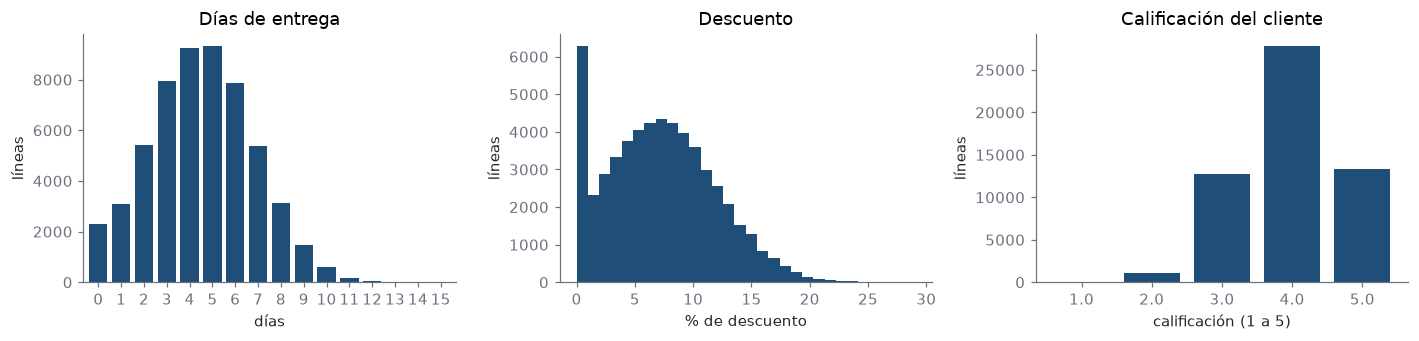

In [14]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 3.2))
raw["dias_entrega"].value_counts().sort_index().plot.bar(ax=ejes[0], color=COLORES["dato"], width=0.8)
ejes[0].set(title="Días de entrega", xlabel="días", ylabel="líneas")
raw["descuento_pct"].plot.hist(bins=30, ax=ejes[1], color=COLORES["dato"])
ejes[1].set(title="Descuento", xlabel="% de descuento", ylabel="líneas")
raw["calificacion_cliente_1a5"].value_counts().sort_index().plot.bar(ax=ejes[2], color=COLORES["dato"], width=0.8)
ejes[2].set(title="Calificación del cliente", xlabel="calificación (1 a 5)", ylabel="líneas")
for eje in ejes:
    eje.tick_params(axis="x", rotation=0)
plt.tight_layout()

**Valores atípicos.** Se revisan con la regla de 1,5 × rango intercuartílico (IQR) en precio (dentro de cada categoría, porque una nevera y una licuadora no son comparables) y en días de entrega.

In [15]:
def atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    rango = q3 - q1
    return ((serie < q1 - 1.5 * rango) | (serie > q3 + 1.5 * rango)).sum()

print("Precio de lista atípico dentro de su categoría:",
      int(raw.groupby("categoria")["precio_lista_cop"].apply(atipicos_iqr).sum()))
print("Días de entrega atípicos:", int(atipicos_iqr(raw["dias_entrega"])),
      "· máximo:", raw["dias_entrega"].max(), "días")
print("Descuento atípico:", int(atipicos_iqr(raw["descuento_pct"])), "· máximo:", raw["descuento_pct"].max(), "%")

Precio de lista atípico dentro de su categoría: 924
Días de entrega atípicos: 231 · máximo: 15 días
Descuento atípico: 210 · máximo: 29.02 %


**Conclusión de la sección 6.**

- Todos los rangos son válidos: precios y costos positivos, descuento entre 0 y 29 %, días de entrega entre 0 y 15, calificación entre 1 y 5, garantía de 12, 24 o 36 meses.
- No hay espacios sobrantes ni variantes de escritura en las categorías, y la jerarquía ciudad → departamento → región es consistente.
- Los atípicos estadísticos son valores posibles (entregas largas, descuentos altos), no errores de digitación. **Se conservan**, porque las entregas largas son justamente parte de lo que el dashboard debe mostrar.

## 7. ¿Los montos son por unidad o por línea?

Si `ingreso_neto_cop` fuera el total de la línea, en líneas de 2 unidades debería ser el doble de `precio_lista_cop × (1 − descuento)`. Se compara la razón entre ambos según las unidades.

In [16]:
esperado_por_unidad = raw["precio_lista_cop"] * (1 - raw["descuento_pct"] / 100)
razon = raw["ingreso_neto_cop"] / esperado_por_unidad
tabla = razon.groupby(raw["unidades"]).agg(["count", "min", "mean", "max"]).round(4)
tabla.columns = ["líneas", "razón mínima", "razón promedio", "razón máxima"]
tabla

,líneas,razón mínima,razón promedio,razón máxima
unidades,,,,
1,51951,0.9999,1.0,1.0001
2,3485,0.9999,1.0,1.0001
3,564,0.9999,1.0,1.0001


In [17]:
print("Diferencia máxima entre ingreso_neto_cop y precio × (1 − descuento):",
      round((raw["ingreso_neto_cop"] - esperado_por_unidad).abs().max(), 1), "COP")
print("Costo / ingreso promedio por número de unidades:",
      (raw["costo_estimado_cop"] / raw["ingreso_neto_cop"]).groupby(raw["unidades"]).mean().round(3).to_dict())

Diferencia máxima entre ingreso_neto_cop y precio × (1 − descuento): 273.5 COP
Costo / ingreso promedio por número de unidades: {1: 0.67, 2: 0.67, 3: 0.668}


**Conclusión.** La razón es 1 en todas las filas, sin importar si la línea tiene 1, 2 o 3 unidades (la razón está entre 0,9999 y 1,0001: la diferencia máxima es de unos 270 pesos en productos de cientos de miles o millones, es decir, redondeo). Por lo tanto `ingreso_neto_cop` es el **precio neto de una unidad**. La relación costo/ingreso tampoco cambia con las unidades, así que `costo_estimado_cop` también es **por unidad**.

**Decisión.** Para obtener los valores de la línea se multiplica por `unidades`:

- `ingreso = ingreso_neto_cop × unidades`
- `costo = costo_estimado_cop × unidades`
- `precio_lista_total = precio_lista_cop × unidades`

Esto afecta a las líneas con más de una unidad. Si no se hiciera, el ingreso total quedaría subestimado:

In [18]:
varias = raw["unidades"] > 1
sin_multiplicar = raw["ingreso_neto_cop"].sum()
multiplicado = (raw["ingreso_neto_cop"] * raw["unidades"]).sum()
print(f"Líneas con más de una unidad: {fmt_entero(varias.sum())} ({fmt_pct(varias.mean())})")
print(f"Ingreso sin multiplicar: {fmt_millones(sin_multiplicar)} · multiplicado: {fmt_millones(multiplicado)} "
      f"· diferencia: {fmt_pct(multiplicado / sin_multiplicar - 1)}")

Líneas con más de una unidad: 4.049 (7,2 %)
Ingreso sin multiplicar: 87.103 M · multiplicado: 94.249 M · diferencia: 8,2 %


## 8. Costo estimado y margen

Se revisa cómo se relaciona el costo con el ingreso, porque de eso depende el KPI de margen.

In [19]:
proporcion_costo = raw["costo_estimado_cop"] / raw["ingreso_neto_cop"]
print(proporcion_costo.describe().round(3).to_string())
print("\nCorrelación de costo/ingreso con:")
for col in ["descuento_pct", "precio_lista_cop", "dias_entrega", "unidades"]:
    print(f"  {col:<18} {proporcion_costo.corr(raw[col]):+.3f}")

count    56000.000
mean         0.670
std          0.052
min          0.580
25%          0.625
50%          0.670
75%          0.715
max          0.760

Correlación de costo/ingreso con:
  descuento_pct      +0.004
  precio_lista_cop   -0.011
  dias_entrega       -0.003
  unidades           -0.002


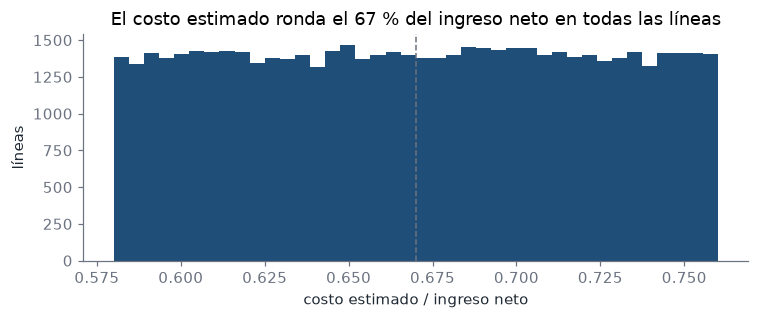

In [20]:
fig, eje = plt.subplots(figsize=(7, 3))
eje.hist(proporcion_costo, bins=40, color=COLORES["dato"])
eje.axvline(proporcion_costo.mean(), color=COLORES["texto_sec"], linestyle="--", linewidth=1)
eje.set(title="El costo estimado ronda el 67 % del ingreso neto en todas las líneas",
        xlabel="costo estimado / ingreso neto", ylabel="líneas")
plt.tight_layout()

**Limitación del dato.** El costo estimado se generó como una proporción aleatoria del ingreso neto (entre 58 % y 76 %, promedio 67 %) que no depende del descuento, del precio ni de ninguna otra variable. En consecuencia, **el margen % será casi el mismo en cualquier segmento**.

Esto no se corrige ni se "fuerza" un hallazgo: se reporta el margen tal como sale y se explica en la sustentación como limitación. Además, como el costo crece con el ingreso neto, el descuento no reduce el margen % en este dataset; su efecto se mide mejor en pesos cedidos (`descuento_cop`).

## 9. Cobertura temporal

In [21]:
print("Desde:", fechas.min().date(), "· hasta:", fechas.max().date())
dias_esperados = (fechas.max() - fechas.min()).days + 1
print("Días con ventas:", fechas.dt.normalize().nunique(), "de", dias_esperados)
cobertura = fechas.groupby(fechas.dt.year).agg(lineas="size", meses=lambda s: s.dt.month.nunique(),
                                                 primer_mes=lambda s: s.min().month, ultimo_mes=lambda s: s.max().month)
cobertura

Desde: 2024-01-01 · hasta: 2026-09-30


Días con ventas: 1004 de 1004


,lineas,meses,primer_mes,ultimo_mes
fecha,,,,
2024,20437,12,1,12
2025,20349,12,1,12
2026,15214,9,1,9


**Conclusión.** Hay ventas todos los días entre el 1 de enero de 2024 y el 30 de septiembre de 2026. **2026 llega solo hasta septiembre**, así que:

- No se compara el total de 2026 con el total de 2025: la comparación con el año anterior siempre usa **el mismo rango de meses** (por ejemplo, ene–sep 2026 contra ene–sep 2025). Así lo hace la app con `data.rango_anio_anterior()`.
- Si se agrupa por mes del año (enero, febrero, …), octubre a diciembre tienen un año menos de datos y se verían más bajos sin serlo.

## 10. Meta de entrega

La variable `entrega_tarde` necesita un umbral. En lugar de elegir un número arbitrario, se busca el punto en que la experiencia del cliente cambia: tasa de devolución y calificación promedio según los días de entrega.

*El análisis completo del costo de las entregas tarde es de la pestaña Operaciones; aquí solo se fija el umbral.*

In [22]:
por_dia = raw.assign(devuelta=raw["devolucion_30_dias"].eq("Sí")).groupby("dias_entrega").agg(
    lineas=("devuelta", "size"),
    tasa_devolucion=("devuelta", "mean"),
    calificacion=("calificacion_cliente_1a5", "mean"),
)
por_dia["tasa_devolucion"] = (por_dia["tasa_devolucion"] * 100).round(1)
por_dia["calificacion"] = por_dia["calificacion"].round(2)
por_dia.T

dias_entrega,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
lineas,2287.00,3071.00,5427.00,7933.00,9264.00,9330.00,7882.00,5377.00,3141.00,1470.00,587.0,163.0,52.00,9.00,6.00,1.0
tasa_devolucion,2.20,2.40,2.50,2.50,2.50,2.40,2.80,2.40,2.50,100.00,100.0,100.0,100.00,100.00,100.00,100.0
calificacion,4.32,4.31,4.18,4.09,4.01,3.94,3.85,3.76,3.68,3.63,3.5,3.3,3.31,2.89,3.33,4.0


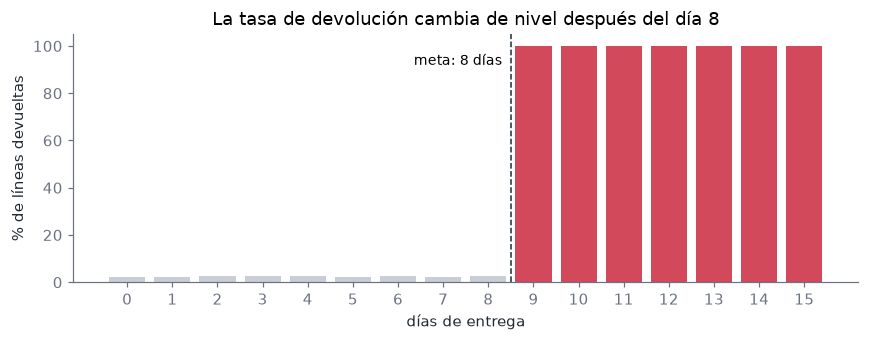

In [23]:
fig, eje = plt.subplots(figsize=(8, 3.2))
colores = [COLORES["alerta"] if d > data.META_DIAS_ENTREGA else COLORES["contexto"] for d in por_dia.index]
eje.bar(por_dia.index, por_dia["tasa_devolucion"], color=colores)
eje.axvline(data.META_DIAS_ENTREGA + 0.5, color=COLORES["texto"], linestyle="--", linewidth=1)
eje.text(data.META_DIAS_ENTREGA + 0.3, 92, f"meta: {data.META_DIAS_ENTREGA} días", ha="right", fontsize=9)
eje.set(title="La tasa de devolución cambia de nivel después del día 8",
        xlabel="días de entrega", ylabel="% de líneas devueltas", ylim=(0, 105), xticks=por_dia.index)
plt.tight_layout()

**Decisión.** Hasta 8 días la tasa de devolución es estable (alrededor de 2,5 %); desde el día 9 cambia de nivel por completo. Se fija la meta en **8 días** (`data.META_DIAS_ENTREGA = 8`) y se define:

`entrega_tarde = dias_entrega > 8`

El umbral sale de los datos y queda en una sola constante, así que si el grupo decide otro valor basta con cambiarla en `data.py`.

## 11. Transformación con `data.limpiar()`

`data.limpiar()` aplica todas las decisiones anteriores y devuelve la tabla con las columnas del **contrato de datos** acordado por el grupo. Variables derivadas:

| Variable | Cálculo |
|---|---|
| `ingreso`, `costo`, `precio_lista_total` | valor por unidad × `unidades` |
| `utilidad` | `ingreso − costo` |
| `descuento_cop` | `precio_lista_total − ingreso` |
| `rango_descuento` | 0–5 %, 5–10 %, 10–15 %, 15–20 %, 20 % o más (límite inferior incluido) |
| `entrega_tarde` | `dias_entrega > META_DIAS_ENTREGA` |
| `devolucion` | `devolucion_30_dias == "Sí"` |
| `anio`, `mes`, `anio_mes`, `trimestre` | derivadas de `fecha` |

In [24]:
df = data.limpiar(raw)
print("Filas:", len(df), "· columnas:", df.shape[1])
print("Columnas = contrato de datos:", list(df.columns) == data.COLUMNAS_PROCESADO)
df.head()

Filas: 56000 · columnas: 27
Columnas = contrato de datos: True


,id_linea_venta,fecha,anio,mes,anio_mes,trimestre,region,departamento,ciudad,categoria,subcategoria,canal,clasificacion_energetica,unidades,precio_lista_total,ingreso,costo,utilidad,descuento_pct,descuento_cop,rango_descuento,dias_entrega,entrega_tarde,devolucion,motivo_devolucion,calificacion,garantia_meses
0,ELEC-000001,2026-02-26,2026,2,2026-02,2026-T1,Caribe,Atlántico,Barranquilla,Lavado,Línea C,Retail aliado,No aplica,1,3435697,3034846,2147688,887158,11.67,400851,10–15 %,5,False,False,Sin devolución,3.0,12
1,ELEC-000002,2025-05-17,2025,5,2025-05,2025-T2,Caribe,Atlántico,Barranquilla,Cocción,Línea C,Tienda propia,A,2,4104100,3832114,2861748,970366,6.63,271986,5–10 %,7,False,False,Sin devolución,3.0,24
2,ELEC-000003,2025-12-16,2025,12,2025-12,2025-T4,Caribe,Bolívar,Cartagena,Refrigeración,Línea A,Retail aliado,A,1,2433262,2208128,1435958,772170,9.25,225134,5–10 %,3,False,False,Sin devolución,4.0,12
3,ELEC-000004,2025-11-29,2025,11,2025-11,2025-T4,Caribe,Magdalena,Santa Marta,Climatización,Línea C,E-commerce,B,1,1650623,1380848,874876,505972,16.34,269775,15–20 %,5,False,False,Sin devolución,3.0,36
4,ELEC-000005,2025-12-13,2025,12,2025-12,2025-T4,Noroccidente,Antioquia,Medellín,Lavado,Línea A,E-commerce,C,1,2743663,2506075,1648857,857218,8.66,237588,5–10 %,0,False,False,Sin devolución,3.0,24


In [25]:
verificaciones = {
    "Sin pérdida de filas": len(df) == len(raw),
    "Solo calificación tiene vacíos": df.drop(columns="calificacion").isna().sum().sum() == 0,
    "utilidad = ingreso − costo": np.allclose(df["utilidad"], df["ingreso"] - df["costo"]),
    "descuento_cop ≥ 0": (df["descuento_cop"] >= 0).all(),
    "Todas las líneas tienen rango de descuento": df["rango_descuento"].notna().all(),
    "Motivo vacío solo si no hubo devolución": (df.loc[~df["devolucion"], "motivo_devolucion"] == data.SIN_DEVOLUCION).all(),
}
for nombre, ok in verificaciones.items():
    print(("OK   " if ok else "FALLA") + "  " + nombre)
assert all(verificaciones.values())

OK     Sin pérdida de filas
OK     Solo calificación tiene vacíos
OK     utilidad = ingreso − costo
OK     descuento_cop ≥ 0
OK     Todas las líneas tienen rango de descuento
OK     Motivo vacío solo si no hubo devolución


In [26]:
df["rango_descuento"].value_counts(sort=False).to_frame("líneas")

,líneas
rango_descuento,
0–5 %,19199
5–10 %,21417
10–15 %,12239
15–20 %,2882
20 % o más,263


## 12. Registros excluidos

**No se excluye ningún registro.**

- No hay duplicados.
- Los faltantes tienen explicación (motivo) o son pocos y aleatorios (calificación), y se manejan sin borrar filas.
- Los atípicos son valores posibles y forman parte del fenómeno que se analiza.
- La inconsistencia de la etiqueta energética no invalida el resto de la fila (ventas, entrega y devolución siguen siendo útiles).

## 13. Validación de los KPI

Se calcula cada KPI "a mano" con pandas y se compara con las funciones de `kpis.py` que usa la app. Si alguna diferencia aparece, la celda falla.

In [27]:
manual = {
    "ingreso": (raw["ingreso_neto_cop"] * raw["unidades"]).sum(),
    "margen": 1 - (raw["costo_estimado_cop"] * raw["unidades"]).sum() / (raw["ingreso_neto_cop"] * raw["unidades"]).sum(),
    "descuento": ((raw["precio_lista_cop"] - raw["ingreso_neto_cop"]) * raw["unidades"]).sum(),
    "tarde": (raw["dias_entrega"] > 8).mean(),
    "devolucion": (raw["devolucion_30_dias"] == "Sí").mean(),
    "satisfaccion": raw["calificacion_cliente_1a5"].mean(),
}
app = kpis.calcular_kpis(df)
formato = {"cop": fmt_millones, "pct": fmt_pct, "nota": fmt_nota}

validacion = pd.DataFrame([
    {"KPI": kpis.KPIS[k]["nombre"],
     "manual (pandas)": formato[kpis.KPIS[k]["tipo"]](manual[k]),
     "kpis.py (app)": formato[kpis.KPIS[k]["tipo"]](app[k]),
     "coinciden": bool(np.isclose(manual[k], app[k]))}
    for k in kpis.KPIS
])
assert validacion["coinciden"].all()
validacion

,KPI,manual (pandas),kpis.py (app),coinciden
0,Ingreso neto,94.249 M,94.249 M,True
1,Margen %,"33,0 %","33,0 %",True
2,Descuento cedido,7.318 M,7.318 M,True
3,Entregas tarde,"4,1 %","4,1 %",True
4,Tasa de devolución,"6,5 %","6,5 %",True
5,Satisfacción,"3,97","3,97",True


El margen se calcula **sobre las sumas** y no como promedio de los márgenes de cada línea. La diferencia existe, aunque en este dataset es pequeña:

In [28]:
promedio_de_margenes = ((df["ingreso"] - df["costo"]) / df["ingreso"]).mean()
print("Margen sobre sumas (correcto):", fmt_pct(kpis.margen_pct(df), 2))
print("Promedio de márgenes por línea:", fmt_pct(promedio_de_margenes, 2))

Margen sobre sumas (correcto): 33,02 %
Promedio de márgenes por línea: 32,99 %


**Comparación entre años con el mismo rango de meses (enero a septiembre).** Es la misma lógica que usan los deltas de las tarjetas KPI.

In [29]:
ene_sep = df[df["mes"] <= 9]
por_anio = {anio: kpis.calcular_kpis(grupo) for anio, grupo in ene_sep.groupby("anio")}
pd.DataFrame({
    anio: {kpis.KPIS[k]["nombre"]: formato[kpis.KPIS[k]["tipo"]](v) for k, v in valores.items()}
    for anio, valores in por_anio.items()
})

,2024,2025,2026
Ingreso neto,26.047 M,25.461 M,25.644 M
Margen %,"33,0 %","33,1 %","33,0 %"
Descuento cedido,2.008 M,1.994 M,2.001 M
Entregas tarde,"4,0 %","4,1 %","4,2 %"
Tasa de devolución,"6,4 %","6,5 %","6,5 %"
Satisfacción,"3,97","3,97","3,97"


## 14. Exportación del CSV procesado

In [30]:
ruta = data.guardar_procesado(df)
print("Guardado en:", ruta.relative_to(data.RAIZ))
print(f"Tamaño: {ruta.stat().st_size / 1e6:.1f} MB")

# Se relee el archivo como lo hará la app y se comprueba que los KPI no cambian
releido = data.tipar_procesado(pd.read_csv(ruta))
kpis_releidos = kpis.calcular_kpis(releido)
assert all(np.isclose(kpis_releidos[k], app[k]) for k in kpis.KPIS)
assert releido["rango_descuento"].cat.ordered and releido["devolucion"].dtype == bool
print("El CSV procesado reproduce los mismos KPI.")

Guardado en: data/processed/electrodomesticos_procesado.csv
Tamaño: 11.7 MB


El CSV procesado reproduce los mismos KPI.


## 15. Bitácora de decisiones y limitaciones

| # | Decisión | Evidencia | Efecto |
|---|---|---|---|
| 1 | `fecha` a datetime y `devolucion_30_dias` a booleano | Todas las fechas convierten; solo hay "Sí" y "No" | Permite filtrar por fechas y contar devoluciones |
| 2 | Multiplicar ingreso, costo y precio por `unidades` | Ingreso = precio × (1 − descuento) en todas las filas, sin importar las unidades | El ingreso total sube en lo que aportan las líneas de 2 y 3 unidades (sección 7) |
| 3 | `motivo_devolucion` vacío → "Sin devolución" | Los vacíos coinciden exactamente con las líneas no devueltas | No se pierde información |
| 4 | Calificación faltante se deja vacía y se excluye del promedio | 2 % de faltantes, repartidos igual en todos los grupos | El promedio no se sesga hacia la mediana |
| 5 | Atípicos se conservan | Son valores posibles, no errores | Las entregas largas quedan en el análisis |
| 6 | Meta de entrega de 8 días; `entrega_tarde = dias_entrega > 8` | La devolución cambia de nivel desde el día 9 | Umbral justificado con los datos, en una constante |
| 7 | Rangos de descuento de 5 puntos, límite inferior incluido | Acuerdo del grupo | Agrupa el descuento para compararlo |
| 8 | No se excluye ningún registro | Sin duplicados ni filas inválidas | Se usan las 56.000 líneas |

**Limitaciones que se deben decir en la sustentación**

1. Los datos son **sintéticos**: sirven para practicar el análisis, no describen una empresa real.
2. El **costo estimado** es una proporción aleatoria del ingreso (58–76 %); por eso el margen % casi no varía entre segmentos.
3. La **etiqueta energética** "No aplica" aparece también en neveras y lavadoras.
4. **2026 llega hasta septiembre**: las comparaciones entre años deben usar el mismo rango de meses.
5. Las relaciones que muestre el dashboard son **asociaciones**, no prueban causalidad.